In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


IMPORT LIBRERY AND TOOLS


In [3]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance

#keras
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

LODE DATA SETS

In [4]:
#Directories for training and testing data
train_dir ='/content/drive/MyDrive/MRI Images/Training/'
test_dir ='/content/drive/MyDrive/MRI Images/Testing/'

# load and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

DATA VISUALIZATION

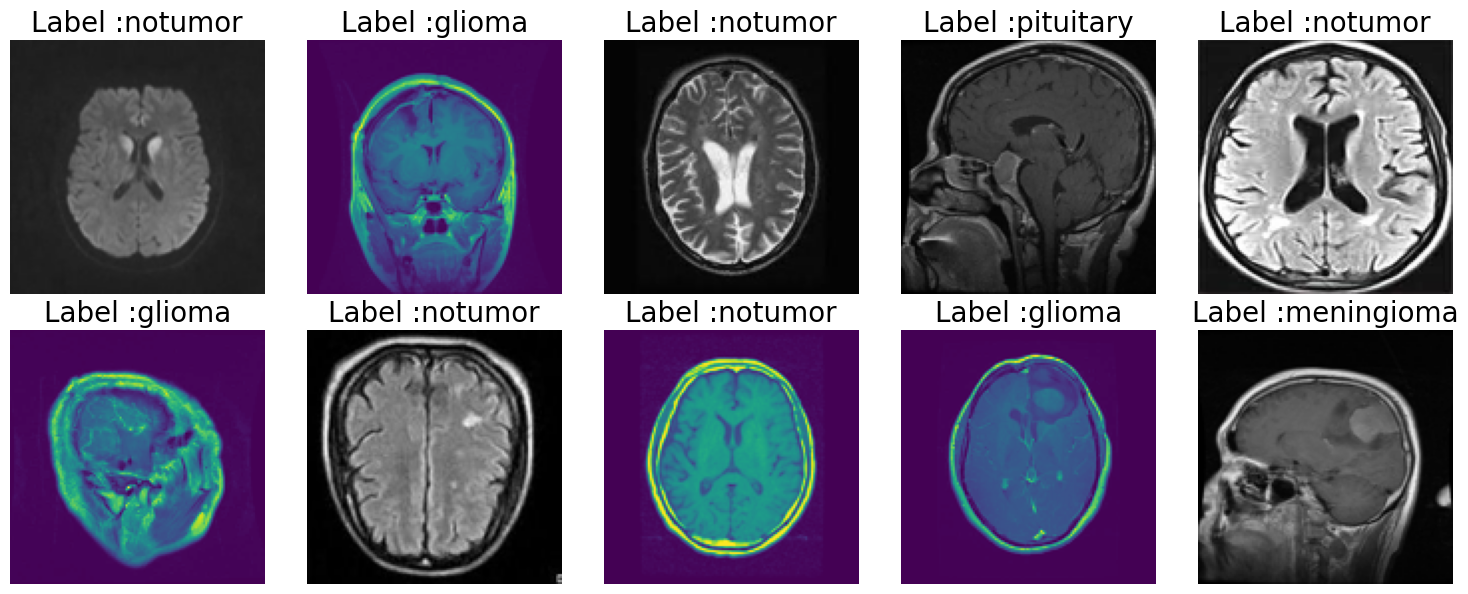

In [5]:
import random
import matplotlib.pyplot as plt

#select random indcies for 10 images
random_indices = random.sample(range(len(train_paths)),10)


#create a figure to display image in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# LOOP THROUGH THE RANDOM INDICES AND DISPLAY IMAGE
for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128, 128))

  # DISPLAY IMAGE
  axes[i].imshow(img)
  axes[i].axis("off")
  axes[i].set_title(f"Label :{train_labels[idx]}", fontsize=20)

plt.tight_layout()
plt.show()



IMAGE PREPROCESSING

In [6]:
import tensorflow as tf

#image augumentation function
def augment_image(image):
  image =Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)/255.0 # Normalization pixel value to [0,1]
  return image

# LOAD IMAGE AND APPLY AUGMENTATION
def open_images(paths):
  images = []
  for path in paths:
    image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    image = augment_image(image)
    images.append(image)
  return np.array(images)

# ENCODER LABELS (CONVERT LABEL NAMES TO INTEGERS )
def encode_label(labels_to_encode):
  unique_labels = sorted(os.listdir(train_dir)) # Sort for consistent encoding
  encoded = [unique_labels.index(label) for label in labels_to_encode]
  return np.array(encoded)


#DATA GENERATOR FOR BATCHING
def datagen(paths, labels, batch_size=20):
  while True:   # ⭐ YAHI MAIN FIX HAI
    for i in range(0, len(paths), batch_size):
      batch_paths = paths[i:i+batch_size]
      batch_images = open_images(batch_paths)
      batch_labels = labels[i:i+batch_size]
      batch_labels = encode_label(batch_labels)

      yield (
          tf.convert_to_tensor(batch_images, dtype=tf.float32),
          tf.convert_to_tensor(batch_labels, dtype=tf.int32)
      )


TRAIN AND VAL PLOTS

In [7]:
# MODEL ARCHITECTURE (128,128,3)
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE,IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# FREEZE ALL LAYERS OF THE VGG16 BASE MODEL
for layer in base_model.layers:
  layer.trainable = False

# SET ONLY THE LAST FEW LAYERS
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# BUILD MODEL
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))) # input layer
model.add(base_model) # VGG16 MODEL
model.add(Flatten()) # FLATTEN LAYER
model.add(Dropout(0.3)) # DROPOUT LAYER (drop randomly 30 neuron)

model.add(Dense(128, activation='relu')) # dense layer
model.add(Dropout(0.2)) # dropout layer

model.add(Dense(len(os.listdir(train_dir)), activation='softmax')) # OUTPUT LAYER

#compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

# parameters

batch_size = 20
steps = len(train_paths) // batch_size
epochs = 5

history = model.fit(
    datagen(train_paths, train_labels, batch_size),
    steps_per_epoch=steps,
    epochs=epochs
)



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 2948s 10s/step - loss: 0.4568 - sparse_categorical_accuracy: 0.8248
Epoch 2/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1230s 4s/step - loss: 0.2326 - sparse_categorical_accuracy: 0.9112
Epoch 3/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1229s 4s/step - loss: 0.1505 - sparse_categorical_accuracy: 0.9437
Epoch 4/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1226s 4s/step - loss: 0.1115 - sparse_categorical_accuracy: 0.9622
Epoch 5/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1231s 4s/step - loss: 0.0737 - sparse_categorical_accuracy: 0.9736


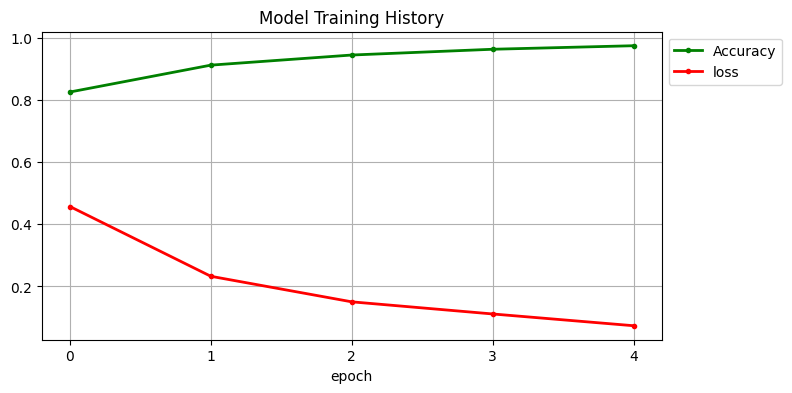

In [12]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range (epochs)])
plt.legend(['Accuracy', 'loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

MODEL CLASSIFICATION REPORT

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 256s 6s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       300
           1       0.95      0.91      0.93       306
           2       0.98      1.00      0.99       405
           3       0.98      0.99      0.98       300

    accuracy                           0.97      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.97      0.97      0.97      1311



MODEL CONFUSION PLOT

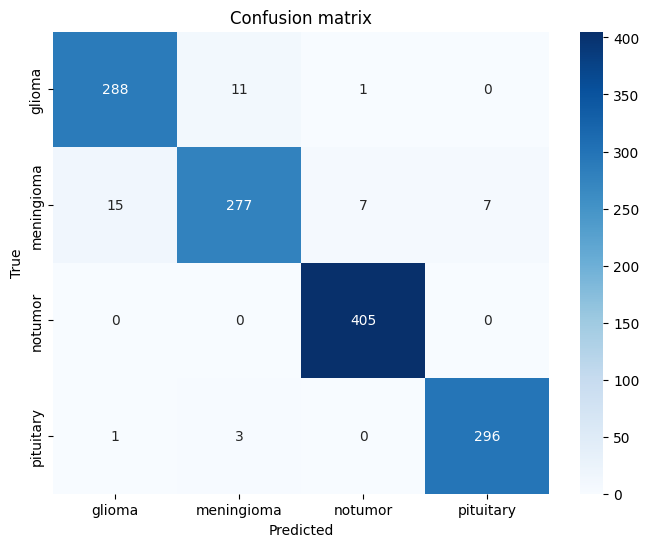

In [15]:
conf_matrix = confusion_matrix(test_labels_encoded,
                               np.argmax(test_predictions, axis=1))

labels = ['glioma', 'meningioma', 'notumor', 'pituitary']  # <-- FIXED ORDER

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

ROC CURVE PLOT

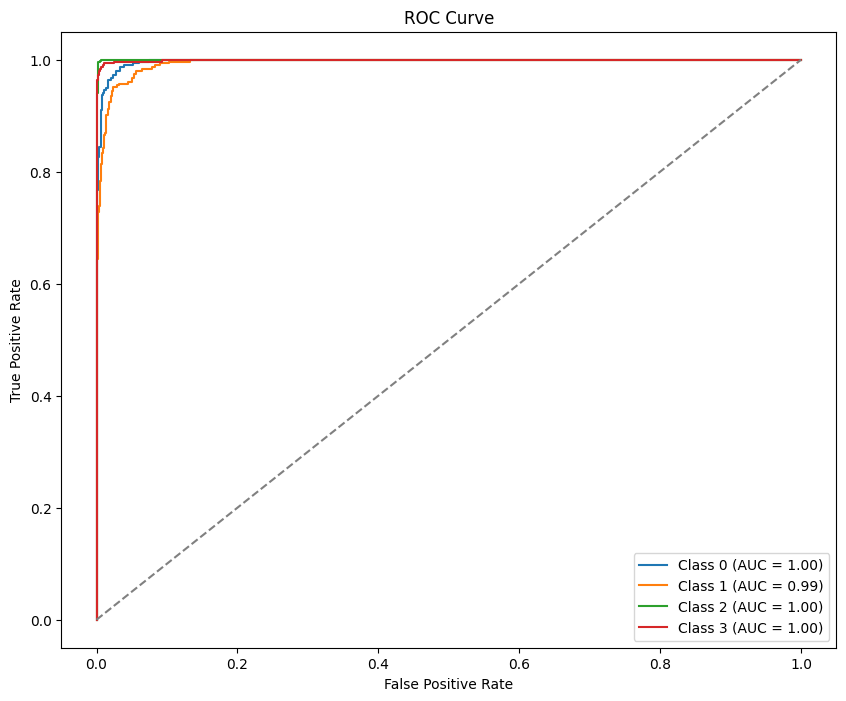

In [16]:
# 4. ROCCURVE AND AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve( test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

SAVE AND LOAD MODEL

In [17]:
# save the entire model
model.save('model.h5')

In [18]:
from tensorflow.keras.models import load_model
# load the trained model
model = load_model('model.h5')

In [19]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os

# ⚠️ SAME order as training (VERY IMPORTANT)
class_labels = sorted(os.listdir(train_dir))

def detect_and_display(image_path, model):
    try:
        # load image
        img = load_img(image_path, target_size=(128, 128))
        img_array = img_to_array(img) / 255.0   # ⭐ NORMALIZATION FIX
        img_array = np.expand_dims(img_array, axis=0)

        # prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions)
        confidence_score = np.max(predictions, axis=1)[0]

        # determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # display
        plt.imshow(load_img(image_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


MRI TUMOR DETECTION SYSTEM TESTING

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step


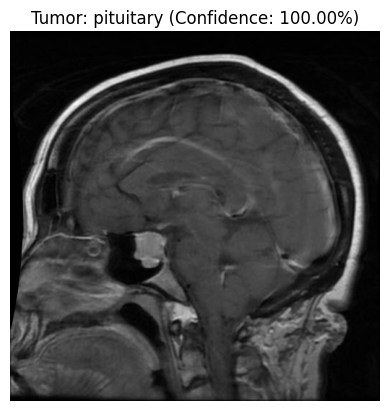

In [20]:
# example usage
image_path ='/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-piTr_0005.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


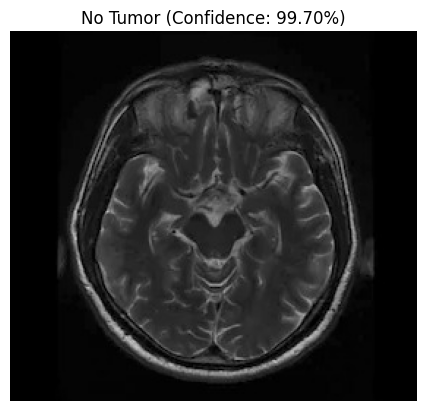

In [21]:
# example usage
image_path ='/content/drive/MyDrive/MRI Images/Testing/notumor/Te-noTr_0006.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


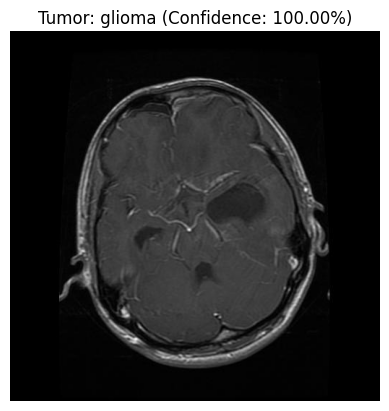

In [22]:
# example usage
image_path ='/content/drive/MyDrive/MRI Images/Testing/glioma/Te-glTr_0008.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step


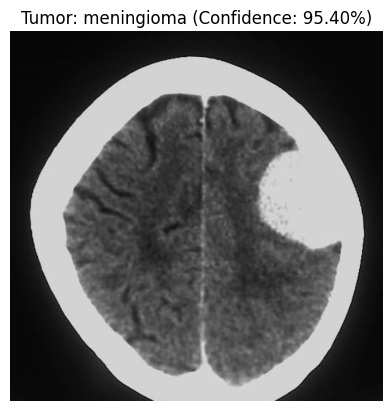

In [23]:
# example usage
image_path ='/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-meTr_0009.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


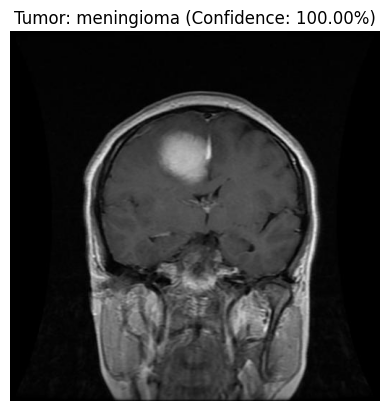

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


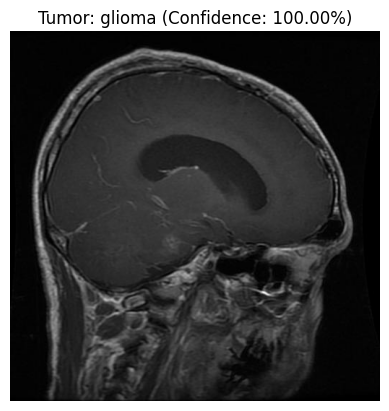

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


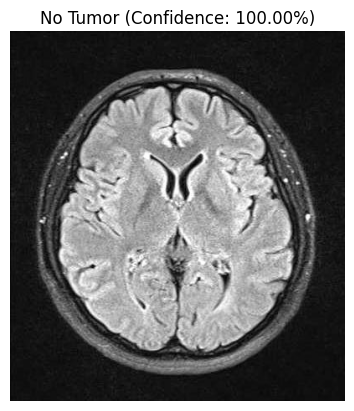

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


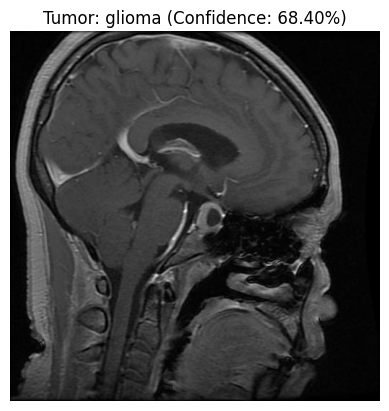

In [24]:
# example usage
image_path ='/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0154.jpg'
detect_and_display(image_path, model)

# example usage
image_path ='/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0179.jpg'
detect_and_display(image_path, model)


# example usage
image_path ='/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0171.jpg'
detect_and_display(image_path, model)

# example usage
image_path ='/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0251.jpg'
detect_and_display(image_path, model)